In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/157183332-157183346-001 - Copy (2)_filtered_5.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_1435.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_3884.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_6730.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_5706.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_8897.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/157185133-157185143-001_filtered_5.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_2815.png
/kaggle/input/new-herlev/NEW_DATASET/validation/normal_superficiel_filtered_nlm/augmented_0_3411.png
/kaggle/input/new-herlev/NEW_DATASET/validat

In [2]:
# Import all modules for model building
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import BatchNormalization, Activation, ZeroPadding2D
from tensorflow.keras.layers import Add, concatenate
import tensorflow as tf


# Import all modules for losses and training
import skimage.measure
import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment
from math import exp, isnan, pow, ceil
from tensorflow.keras.metrics import Precision, Recall, IoU
from tensorflow.keras.callbacks import ModelCheckpoint

# Import all modules for data providing
import glob
import itertools
import os
import random
from sklearn.model_selection import train_test_split

In [3]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, ZeroPadding2D, Add, concatenate, MaxPooling2D, UpSampling2D, GlobalAveragePooling2D, Dropout, Dense, Flatten, AveragePooling2D, Reshape
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

# Set your data directories and parameters
train_data_dir = '/kaggle/input/new-herlev/NEW_DATASET/train'
test_data_dir = '/kaggle/input/new-herlev/NEW_DATASET/test'
val_data_dir = '/kaggle/input/new-herlev/NEW_DATASET/validation'

img_width, img_height = 224, 224
batch_size = 128

train_datagen = ImageDataGenerator(
    brightness_range=[0.8, 1.2],
    rescale=1.0/255,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.3,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

val_generator = val_datagen.flow_from_directory(
    val_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Build ResNet50V2 Backbone
def build_resnet50v2_backbone(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)
    backbone = ResNet50V2(weights="imagenet", include_top=False, input_tensor=inputs)
    x = backbone.get_layer("conv4_block6_out").output  
    return inputs, x

# Fixed DeepLabV3+ DSPP Module
def dspp(x, filters=256):
    conv_1x1 = Conv2D(filters, (1, 1), padding="same", activation="relu")(x)
    conv_3x3_1 = Conv2D(filters, (3, 3), dilation_rate=6, padding="same", activation="relu")(x)
    conv_3x3_2 = Conv2D(filters, (3, 3), dilation_rate=12, padding="same", activation="relu")(x)
    conv_3x3_3 = Conv2D(filters, (3, 3), dilation_rate=18, padding="same", activation="relu")(x)

    # Fixed Global Average Pooling
    gap = GlobalAveragePooling2D()(x)
    gap = Dense(filters, activation="relu")(gap)
    gap = BatchNormalization()(gap)
    gap = Reshape((1, 1, filters))(gap)  # ✅ Using Reshape instead of expand_dims
    gap = UpSampling2D(size=(x.shape[1], x.shape[2]), interpolation="bilinear")(gap)

    x = concatenate([conv_1x1, conv_3x3_1, conv_3x3_2, conv_3x3_3, gap])
    x = Conv2D(filters, (1, 1), padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    return x

# Custom 7-layer Head
def custom_7_layer_head(x, num_classes=7):
    x = Flatten()(x)
    x = Dense(512, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation="softmax")(x)
    return outputs

# DeepLabV3 Model
def build_deeplabv3(input_shape=(224, 224, 3), num_classes=7):
    inputs, x = build_resnet50v2_backbone(input_shape)
    x = dspp(x)
    outputs = custom_7_layer_head(x, num_classes)
    return Model(inputs, outputs, name="DeepLabV3_ResNet50V2_Custom7")

# Compile, Train & Evaluate
model = build_deeplabv3()

# AdamW for better generalization
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3, min_lr=5e-7)
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("deeplabv3_best.keras", save_best_only=True, monitor='val_accuracy', mode='max')

# Fit Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=[reduce_lr, early_stopping, checkpoint]
)


# Save Model
model.save("deeplabv3_final.keras")

# Evaluate Model
train_loss, train_accuracy = model.evaluate(train_generator)
val_loss, val_accuracy = model.evaluate(val_generator)
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Train Accuracy: {train_accuracy * 100:.2f}% | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}% | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}% | Test Loss: {test_loss:.4f}")

model.summary()


Found 12110 images belonging to 7 classes.
Found 2083 images belonging to 7 classes.
Found 3111 images belonging to 7 classes.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 589s 4s/step - accuracy: 0.3299 - loss: 2.0104 - val_accuracy: 0.4131 - val_loss: 1.9499 - learning_rate: 1.0000e-04
Epoch 2/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.5597 - loss: 1.1964 - val_accuracy: 0.4044 - val_loss: 2.0667 - learning_rate: 1.0000e-04
Epoch 3/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.6330 - loss: 0.9564 - val_accuracy: 0.6458 - val_loss: 0.9828 - learning_rate: 1.0000e-04
Epoch 4/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6682 - loss: 0.8499 - val_accuracy: 0.7197 - val_loss: 0.7061 - learning_rate: 1.0000e-04
Epoch 5/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7128 - loss: 0.7306 - val_accuracy: 0.7329 - val_loss: 0.6823 - learning_rate: 1.0000e-04
Epoch 6/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.7366 - loss: 0.6782 - val_accuracy: 0.7866 - val_loss: 0.6153 - learning_rate: 1.0000e-04
Epoch 7/60
95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7587 - loss: 0.6

Model: "DeepLabV3_ResNet50V2_Custom7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_conv[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_bn    │ (None, 56, 56, 64)     │            256 │ pool1_pool[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_relu  │ (None, 56, 56, 64)     │              0 │ conv2_block1_preact_b… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,096 │ conv2_block1_preact_r… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_pad        │ (None, 58, 58, 64)     │              0 │ conv2_block1_1_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,864 │ conv2_block1_2_pad[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_preact_r… │
│ (Conv2D)             

 Total params: 69,240,343 (264.13 MB)

 Trainable params: 23,070,855 (88.01 MB)

 Non-trainable params: 27,776 (108.50 KB)

 Optimizer params: 46,141,712 (176.02 MB)

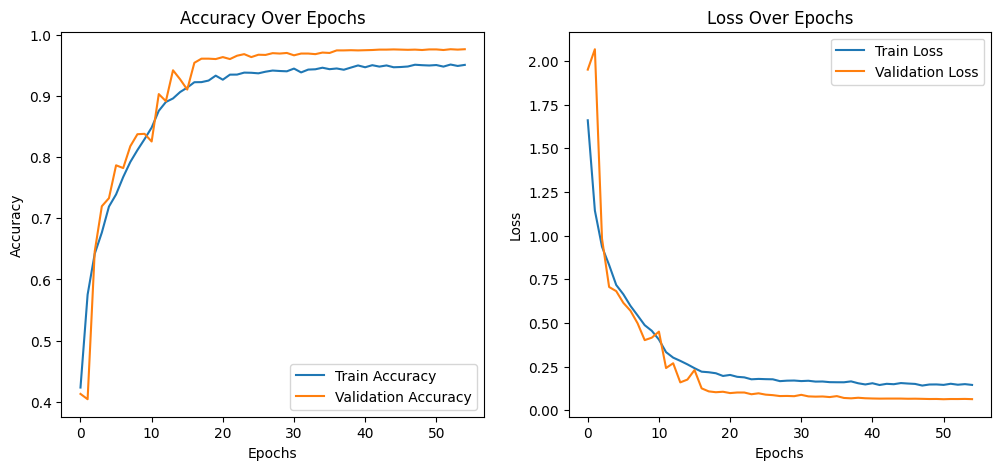

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 680ms/step


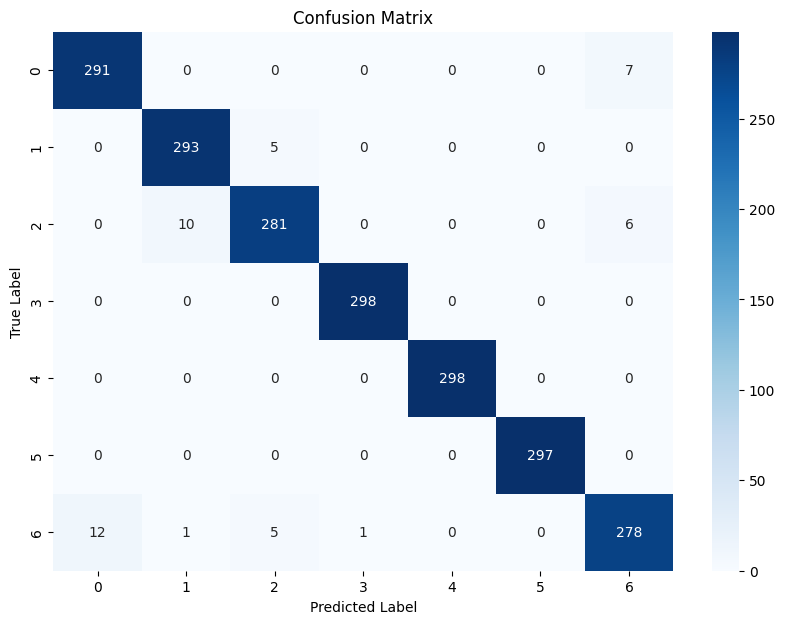

Classification Report:
                                   precision    recall  f1-score   support

  carcinoma_in_situ_filtered_nlm       0.96      0.98      0.97       298
   light_dysplastic_filtered_nlm       0.96      0.98      0.97       298
moderate_dysplastic_filtered_nlm       0.97      0.95      0.96       297
    normal_columnar_filtered_nlm       1.00      1.00      1.00       298
normal_intermediate_filtered_nlm       1.00      1.00      1.00       298
 normal_superficiel_filtered_nlm       1.00      1.00      1.00       297
  severe_dysplastic_filtered_nlm       0.96      0.94      0.95       297

                        accuracy                           0.98      2083
                       macro avg       0.98      0.98      0.98      2083
                    weighted avg       0.98      0.98      0.98      2083



In [7]:
# Save the model after training
model.save("deeplabv3_final.h5")

from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
loaded_model = load_model("deeplabv3_final.h5")
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')
plt.show()

# Generate Predictions
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
class_labels = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)
